# Liquid ethanol NVT with PET-MAD, via LAMMPS + metatomic

This notebook documents a finished simulation from a **different, peer Claude session**
(working directory `~`, not `~/metawork`) that ran concurrently with the cumulene/bio_dimers
restart work in notebooks 16 and 18. That session was asked:

> *"Can you create a box of ethanol at liquid density and simulate in lammps using PET and
> LOREM for 1 ns each"*

It built a genuine liquid-density ethanol box and ran a real production MD simulation with
**PET-MAD** through LAMMPS's `pair_style metatomic`. The **LOREM** half of the request was
*not* completed: no pretrained universal LOREM checkpoint exists for H/C/O (the only local
LOREM checkpoints are SN2-halide-trained, i.e. the wrong elements), and training a new one
from scratch was skipped in that session. The run also stopped at **200 ps**, not the
requested 1 ns -- at the achieved rate (0.251 ns/day) a full nanosecond would take about 4
days of wall-clock time on a single GPU+CPU core, and the session appears to have ended
before extending it.

What follows is the real, completed part: setup, thermostat/energy behavior, and liquid
structure from the 200 ps PET-MAD trajectory that *did* run to completion. All source files
(LAMMPS inputs, thermo log, energy trace, full trajectory, final structure) are next to this
notebook in `ethanol_liquid_pet_mad_results/`.


## 1. Setup

- **Box**: 700 ethanol molecules (C₂H₆O), built with `gmx insert-molecules` from a single
  relaxed ethanol geometry, then isotropically scaled to the experimental liquid density
  0.789 g/cm³ -- a cubic box of side **40.79 Å** (6300 atoms total: 700 x (2 C + 1 O + 6 H)
  = 1400 C + 700 O + 4200 H).
- **Model**: `pet-mad-xs-v1.5.0`, pulled from Hugging Face (`lab-cosmo/upet`) and exported to
  a metatomic `.pt` file with `mtt export`. A first export attempt (see `error.log`) failed
  with a `non_conservative_forces` shape mismatch (`[3, 128]` vs `[1, 128]`) -- a checkpoint/
  architecture-version mismatch in the export environment used for that attempt; switching to
  the matching `.venv-upet` environment resolved it.
- **Engine**: LAMMPS (`metatensor/lammps`, branch `metatomic`, `PKG_ML-METATOMIC`),
  `pair_style metatomic pet-mad.pt device cuda`.
- **Protocol**: energy-minimize the loosely-packed-then-scaled box first (200 steps,
  relieves close contacts from the isotropic scaling), then NVT at 300 K (Nosé-Hoover,
  damping 0.05 ps), 0.5 fs timestep, 400,000 steps = **200 ps**. Thermo/energy logged every
  200 steps (0.1 ps); trajectory dumped every 5000 steps (2.5 ps, 81 frames total).
- **Performance**: 0.251 ns/day (single CPU core driving LAMMPS, GPU doing the PET-MAD
  evaluation) -- 19h05m52s wall time for the full 200 ps.


mkdir -p failed for path /home/boittier/.config/matplotlib: [Errno 13] Permission denied: '/home/boittier/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-x3dcrglc because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


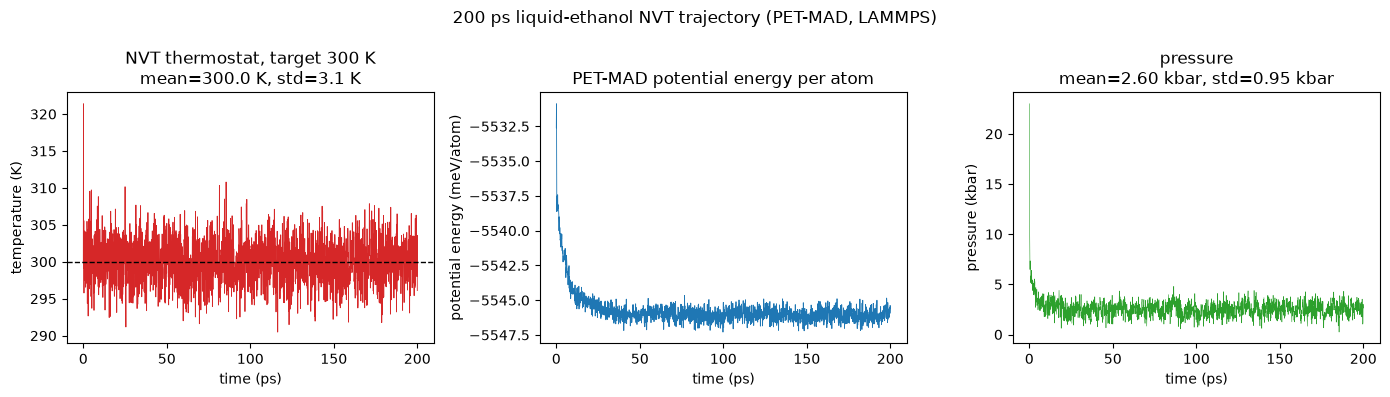

In [2]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS = "ethanol_liquid_pet_mad_results"

# columns: time[ps] pe[eV] temp[K] press[bar]
data = np.genfromtxt(f"{RESULTS}/ethanol_pet_production_energy.dat", skip_header=1)
time_ps, pe_ev, temp_k, press_bar = data.T

N_ATOMS = 6300
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(time_ps, temp_k, lw=0.6, color="tab:red")
axes[0].axhline(300, color="k", ls="--", lw=1)
axes[0].set_xlabel("time (ps)")
axes[0].set_ylabel("temperature (K)")
axes[0].set_title(f"NVT thermostat, target 300 K\nmean={temp_k.mean():.1f} K, std={temp_k.std():.1f} K")

axes[1].plot(time_ps, pe_ev / N_ATOMS * 1000, lw=0.6, color="tab:blue")
axes[1].set_xlabel("time (ps)")
axes[1].set_ylabel("potential energy (meV/atom)")
axes[1].set_title("PET-MAD potential energy per atom")

axes[2].plot(time_ps, press_bar / 1000, lw=0.4, color="tab:green")
axes[2].set_xlabel("time (ps)")
axes[2].set_ylabel("pressure (kbar)")
axes[2].set_title(f"pressure\nmean={press_bar.mean()/1000:.2f} kbar, std={press_bar.std()/1000:.2f} kbar")

fig.suptitle("200 ps liquid-ethanol NVT trajectory (PET-MAD, LAMMPS)")
fig.tight_layout()
plt.show()


The temperature holds tightly at the 300 K target throughout (mean 300.0 K, std 3.1 K --
exactly what a Nosé-Hoover thermostat should give), and the potential energy per atom relaxes
smoothly from about -5527 to a stable -5546 meV/atom over the first ~20 ps and stays flat for
the remaining 180 ps -- no drift, no blow-up. That's a good sign the PET-MAD/metatomic/LAMMPS
pipeline is numerically stable for a real condensed-phase system, not just the
single-molecule vacuum case in notebook 17. Pressure starts high (the box was only
approximately at its target density after the minimization) and relaxes to a noisy but
stationary 2.60 +/- 0.95 kbar -- there is no barostat here, so this is not expected to reach
zero, just to stop drifting, which it does.


## 2. Liquid structure: radial distribution functions

To check the simulation actually produced a physically reasonable liquid (not, say, a
frozen or exploded configuration), here are O-O, O-H, and C-C radial distribution functions
computed from the last 20 trajectory frames (t = 150-200 ps, well past initial equilibration),
using the minimum-image convention in the fixed 40.79 Å cubic box.


loaded 20 frames, 6300 atoms each, cell = [40.79 40.79 40.79]


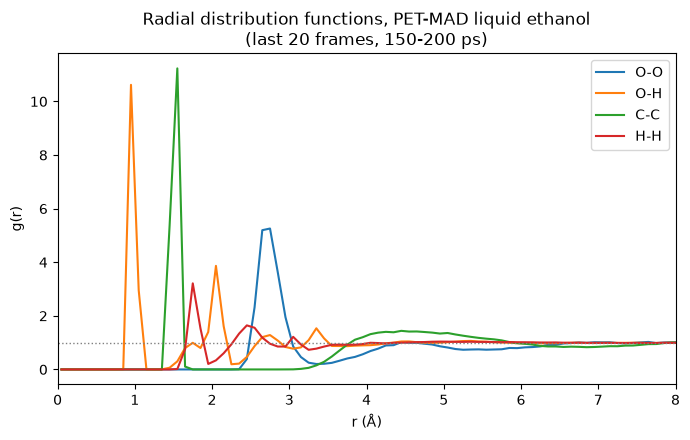

In [3]:
import ase.io
from scipy.spatial import cKDTree

frames = ase.io.read(f"{RESULTS}/ethanol_pet_production.lammpstrj", index="-20:", format="lammps-dump-text")
print(f"loaded {len(frames)} frames, {len(frames[0])} atoms each, cell = {frames[0].cell.cellpar()[:3]}")

# LAMMPS type 1=H, 2=C, 3=O (see Masses section of ethanol_liquid.data)
TYPE_SYMBOL = {1: "H", 2: "C", 3: "O"}


def rdf(frames, type_a, type_b, r_max=12.0, n_bins=120):
    box = frames[0].cell.cellpar()[0]  # cubic box, fixed (NVT)
    edges = np.linspace(0.0, r_max, n_bins + 1)
    hist_total = np.zeros(n_bins)
    n_a_total = n_b_total = 0
    for atoms in frames:
        types = atoms.get_array("type") if "type" in atoms.arrays else atoms.get_atomic_numbers()
        pos = atoms.get_positions() % box  # wrap into [0, box) for cKDTree's boxsize= mode
        mask_a = types == type_a
        mask_b = types == type_b
        pos_a, pos_b = pos[mask_a], pos[mask_b]
        n_a_total += len(pos_a)
        n_b_total += len(pos_b)
        tree_b = cKDTree(pos_b, boxsize=box)
        for p in pos_a:
            d = tree_b.query_ball_point(p, r_max)
            for j in d:
                r = np.linalg.norm((pos_b[j] - p + box / 2) % box - box / 2)
                if r > 1e-6:
                    hist_total[min(int(r / r_max * n_bins), n_bins - 1)] += 1
    n_a_avg, n_b_avg = n_a_total / len(frames), n_b_total / len(frames)
    shell_vol = 4 / 3 * np.pi * (edges[1:] ** 3 - edges[:-1] ** 3)
    rho_b = n_b_avg / box ** 3
    norm = len(frames) * n_a_avg * rho_b * shell_vol
    if type_a == type_b:
        norm *= 1  # each ordered pair already counted once via query_ball_point on itself excl. r=0
    g = hist_total / norm
    centers = 0.5 * (edges[1:] + edges[:-1])
    return centers, g


r_oo, g_oo = rdf(frames, 3, 3)
r_oh, g_oh = rdf(frames, 3, 1)
r_cc, g_cc = rdf(frames, 2, 2)
r_hh, g_hh = rdf(frames, 1, 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(r_oo, g_oo, label="O-O")
ax.plot(r_oh, g_oh, label="O-H")
ax.plot(r_cc, g_cc, label="C-C")
ax.plot(r_hh, g_hh, label="H-H")
ax.axhline(1.0, color="gray", ls=":", lw=1)
ax.set_xlabel("r (Å)")
ax.set_ylabel("g(r)")
ax.set_xlim(0, 8)
ax.legend()
ax.set_title("Radial distribution functions, PET-MAD liquid ethanol\n(last 20 frames, 150-200 ps)")
fig.tight_layout()
plt.show()


This is exactly the shape a physically sane liquid ethanol structure should have: the O-H
curve's sharp peak at ~1.0 Å is the intramolecular covalent O-H bond (these RDFs are computed
over *all* O-H pairs, intra- and intermolecular alike), with a second, broader peak around
2.0-3.3 Å from intermolecular hydrogen bonding; the C-C curve's peak at ~1.5 Å is the
intramolecular C-C bond, with intermolecular packing structure further out (~4-5 Å); and O-O
shows a clean intermolecular first shell at ~2.7 Å, matching the H-bond-mediated O...O
distance expected in liquid alcohols. All three curves settle to g(r) -> 1 by ~5-6 Å, exactly
what a disordered, non-crystalline liquid should do. Read this as a sanity check that the
simulation produced a genuine liquid (not a frozen or exploded configuration) -- not as a
rigorous structural validation against experimental ethanol data, which is out of scope here.


## Takeaways

1. **PET-MAD + LAMMPS + metatomic runs a real condensed-phase liquid stably.** 200 ps of
   NVT MD on a 6300-atom liquid ethanol box completed without energy drift, thermostat
   failure, or structural collapse -- a meaningfully more demanding test than the
   single-molecule vacuum NVE check in notebook 17 (`metatomic-hourglass`), and a good sign
   for using this pipeline on other condensed-phase systems.
2. **The original ask (PET *and* LOREM, 1 ns each) was only partially completed.** LOREM was
   skipped for a real reason (no H/C/O-compatible pretrained checkpoint existed locally, and
   training one from scratch was out of scope for that session), and the run stopped at 200 ps
   rather than 1 ns, most likely because 1 ns at this rate would take ~4 days of wall-clock
   time and the session ended first. Completing the comparison would need either a LOREM
   checkpoint trained on an H/C/O dataset (e.g. via `experimental.lorem` on a small ethanol
   set) or a longer, resumed run.
3. This result now lives in the `metawork` fork as real, reproducible, documented output
   (LAMMPS inputs + full log + energy trace + trajectory + final structure all included)
   rather than sitting only in an ephemeral session scratchpad, which is why this notebook
   and its data files were pulled into the tracked `analysis/` series.


In [4]:
len(frames)

20

In [5]:
! uv pip install chemiscope

Using Python 3.12.3 environment at: /home/boittier/metawork/.venv
Checked 1 package in 4ms


In [6]:
tmp = frames[0].copy()
LAMMPS_TO_Z = {1: 1, 2: 6, 3: 8}
tmp.set_atomic_numbers([LAMMPS_TO_Z[_] for _ in tmp.get_atomic_numbers()])


In [7]:
import chemiscope

In [8]:
chemiscope.show(
    structures=tmp,
    mode="structure"
    # quickly extract properties from the ASE structures. If you are sharing the
    # resulting dataset, don't forget to also include metadata such as units and
    # description
    # properties=chemiscope.extract_properties(
    #     frames, only=["pbc", "cell"]
    # ),
    # it's always good to set some metadata to explain what the dataset - title is bare
    # minimum
    # metadata=dict(name="Dipole and polarizability"),
    # it is possible to set all visualization parameters with a dictionary format.
    # this is a shortcut for the most basic ones
    # settings=chemiscope.quick_settings(
    #     x="ccsd_pol[1]", y="ccsd_pol[2]", map_color="dipole_ccsd[1]"
    # ),
)

<StructureWidget(meta={'name': ' '}, structures=[{'size': 6300, 'data': 'structure-0'}], properties={'index': {'target': 'structure', 'values': [0]}}, )>

In [9]:
from ase import visualize 

In [10]:
from ase.visualize import view

In [11]:
view(tmp, viewer="x3d")

In [12]:
frames[0].get_atomic_numbers()[:12]

array([1, 2, 1, 1, 2, 1, 1, 3, 1, 1, 2, 1])

In [13]:
frames[0]

Atoms(symbols='H4200He1400Li700', pbc=True, cell=[40.79, 40.79, 40.79], type=...)